In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import matplotlib.colors as mcolors
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
import arviz as az
import colorsys
from matplotlib.patches import Patch

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "2" # second gpu
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

from utils import *

az.style.use("arviz-doc")
plt.rcParams['figure.dpi'] = 140

from matplotlib import rc

rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})
rc('text', usetex=False)

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv')
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [2]:
import jax.numpy as jnp
import jax.random as jr
from jax import lax
from jax import vmap
import optax

from jax.extend import backend
print(backend.get_backend().platform)

gpu


In [3]:
def train_hmm(model, emissions, inputs, verbose = True):
    parameters, properties = model.initialize(key=jr.PRNGKey(1), method="prior", emissions = emissions)
    fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = emissions, inputs = inputs, num_iters = 10,verbose = verbose)
    return model, fit_params, lps

def scale_to_bounds(x, axis=0, eps=1e-3):
    """
    Linearly rescales x along `axis` so that
      min → eps, max → 1-eps,
    and everything else is in between.
    """
    # compute min and max (keepdims so we can broadcast)
    mn = x.min(axis=axis, keepdims=True)
    mx = x.max(axis=axis, keepdims=True)
    # normalize to [0,1]
    x0 = (x - mn) / (mx - mn)
    # stretch to [eps, 1-eps]
    return x0 * (1 - 2*eps) + eps
  
def impute_with_median(data):
    median_rt = np.nanmedian(data)
    rt_imputed = data.copy()
    rt_imputed[rt_imputed == 0] = median_rt
    return rt_imputed

def impute_with_lin_interpolation(data):
    oshape = data.shape
    rt_imputed = data.flatten().copy()
    idx = np.arange(rt_imputed.size)
    good = rt_imputed != 0
    
    # interpolate where values are zero
    rt_imputed[rt_imputed == 0] = np.interp(
        idx[~good], 
        idx[good], 
        rt_imputed[good], 
    )
    return rt_imputed.reshape(oshape)

In [4]:
rdf = r_table.copy()

# 1) Compute previous-trial target, response, reaction time & error
rdf['prev_target'] = rdf.groupby(['subj', 'sess', 'run'])['t_calib'].shift(1)
rdf['prev_resp']   = rdf.groupby(['subj', 'sess', 'run'])['resp'].shift(1)
rdf['prev_rt']     = rdf.groupby(['subj', 'sess', 'run'])['f_resp'].shift(1)
rdf['prev_error']  = rdf.groupby(['subj', 'sess', 'run'])['resp_err'].shift(1)
rdf['prev_target'] = rdf['prev_target'].fillna(rdf['t_calib'])
rdf['prev_resp']   = rdf['prev_resp'].fillna(rdf['resp'])
rdf['prev_rt']     = rdf['prev_rt'].fillna(rdf['f_resp'])
rdf['prev_error']  = rdf['prev_error'].fillna(rdf['resp_err'])

# 2) Reshape metadata into (n_trials, T, 1)
n_trials = rdf.shape[0] // 120
T = 120
reshape = lambda x: x.values.reshape(n_trials, T, 1).astype(np.float32)

baseline_bias    = np.ones((n_trials, T, 1), dtype=np.float32)
attention        = (rdf['att'] == "focused").astype(np.float32)
coherence        = (rdf['coh'] == "high").astype(np.float32)
expectation      = (rdf['exp_al'] == "expected").astype(np.float32)

attention   = reshape(attention)
coherence   = reshape(coherence)
expectation = reshape(expectation)

# 3) Error predictor for RT: signed error in radians
# resp_err = np.deg2rad(rdf['resp_err'])
# resp_err = reshape(resp_err)

# 4) Stimuli and history for RA
stim       = np.deg2rad(rdf['t_calib'])
prev_stim  = np.deg2rad(rdf['prev_target'])
prev_resp  = np.deg2rad(rdf['prev_resp'])

# wrap to [-pi, pi]
wrap = lambda x: ((x + np.pi) % (2*np.pi)) - np.pi
stim      = wrap(reshape(stim))
prev_stim = wrap(reshape(prev_stim))
prev_resp = wrap(reshape(prev_resp))

# 4b) Previous reaction time and error
prev_rt_raw = (rdf['prev_rt'].values - 250).reshape(n_trials, T, 1) * (1000/120)
prev_reaction_time = impute_with_lin_interpolation(prev_rt_raw)

prev_err_raw = rdf['prev_error'].values.reshape(n_trials, T, 1)
prev_err_neg_mask = rdf['prev_error'].values.reshape(n_trials, T, 1) < 0
prev_err_raw[prev_err_neg_mask] = prev_err_raw[prev_err_neg_mask] * -1
prev_response_error = prev_err_raw

# 5) Reaction time (ms)
rt_raw = (rdf['f_resp'].values - 250).reshape(n_trials, T, 1) * (1000/120)
# reaction_time = np.clip(rt_raw, 0.01, None).astype(np.float32)
reaction_time = impute_with_lin_interpolation(rt_raw)

# 6) Response angle in radians, wrapped
response_angle = np.deg2rad(rdf['resp']).values
response_angle = wrap(response_angle.reshape(n_trials, T, 1))

# 7) Response error for emissions (positive)
err_raw = rdf['resp_err'].values.reshape(n_trials, T, 1)
err_neg_mask = rdf['v_err'].values.reshape(n_trials, T, 1) < 0
err_raw[err_neg_mask] = err_raw[err_neg_mask] * -1
response_error = err_raw
abs_response_error = np.abs(response_error)

# 8) Build feature blocks
# RT features: [1, Error, Prev_RT, Att, Coh, Exp]
x_rt = np.concatenate([
    baseline_bias,
    abs_response_error,
    prev_reaction_time,
    attention, coherence, expectation
], axis=-1)

# RA features: [1, stim, prev_stim, prev_resp, Att, Coh, Exp]
x_ra = np.concatenate([
    baseline_bias,
    stim, prev_stim, prev_resp,
    attention, coherence, expectation
], axis=-1)

# RE features: [1, RT, Prev_Error, Att, Coh, Exp]
x_re = np.concatenate([
    baseline_bias,
    reaction_time,
    prev_response_error,
    attention, coherence, expectation
], axis=-1)

x_rt = jnp.array(x_rt)
x_ra = jnp.array(x_ra)
x_re = jnp.array(x_re)

y_rt = jnp.array(reaction_time)
y_ra = jnp.array(response_angle)
y_re = jnp.array(response_error)

# Verify shapes
print("inputs shape:", (x_rt.shape,x_ra.shape,x_re.shape) )
print("emissions shape:", (y_rt.shape,y_ra.shape,y_re.shape) )


inputs shape: ((288, 120, 6), (288, 120, 7), (288, 120, 6))
emissions shape: ((288, 120, 1), (288, 120, 1), (288, 120, 1))


In [5]:
to_train = ((x_rt, y_rt), (x_ra, y_ra), (x_re, y_re))
input_dims = (x_rt.shape[-1], x_ra.shape[-1], x_re.shape[-1])
emission_dims = (y_rt.shape[-1], y_ra.shape[-1], y_re.shape[-1])
bmodels = (BlockHMMrt, BlockHMMra, BlockHMMre)
onemodels = (BlockOneRT, BlockOneRA, BlockOneRE)
colors = ('#1f77b4', '#ff7f0e', '#2ca02c')
cmaps = [mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["white", color], N=256) for color in colors]
titles = ('Reaction Time', 'Response Angle', 'Response Error')
chosen_states = ( 2, 2, 2)
dirs = (
    './caches/rt',
    './caches/ra',
    './caches/re'
)

In [6]:
bar_kwargs = {
    'edgecolor': 'black',
    'linewidth': 1.5,
    'width': 0.3,
    'rot': 0,
}

In [7]:
# global parameters

with open(f'./caches/rt/global_params.pkl', 'rb') as f: rt_global_params = pickle.load(f)
with open(f'./caches/ra/global_params.pkl', 'rb') as f: ra_global_params = pickle.load(f)
with open(f'./caches/re/global_params.pkl', 'rb') as f: re_global_params = pickle.load(f)

# cross-validation
with open(f'./caches/rt/sub_crossval_results.pkl', 'rb') as f: rt_sub_crossval = pickle.load(f)
with open(f'./caches/ra/sub_crossval_results.pkl', 'rb') as f: ra_sub_crossval = pickle.load(f)
with open(f'./caches/re/sub_crossval_results.pkl', 'rb') as f: re_sub_crossval = pickle.load(f)
    
# One-state models
with open(f'./caches/rt/one_crossval_results.pkl', 'rb') as f: rt_one_state = pickle.load(f)
with open(f'./caches/ra/one_crossval_results.pkl', 'rb') as f: ra_one_state = pickle.load(f)
with open(f'./caches/re/one_crossval_results.pkl', 'rb') as f: re_one_state = pickle.load(f)

# subject-specific parameters
with open(f'./caches/rt/sub_params.pkl', 'rb') as f: rt_sub_params = pickle.load(f)
with open(f'./caches/ra/sub_params.pkl', 'rb') as f: ra_sub_params = pickle.load(f)
with open(f'./caches/re/sub_params.pkl', 'rb') as f: re_sub_params = pickle.load(f)

# ml states
with open(f'./caches/rt/ml_states.pkl', 'rb') as f: rt_ml_states = pickle.load(f)
with open(f'./caches/ra/ml_states.pkl', 'rb') as f: ra_ml_states = pickle.load(f)
with open(f'./caches/re/ml_states.pkl', 'rb') as f: re_ml_states = pickle.load(f)

# smoothed posteriors
with open(f'./caches/rt/smoothed_states.pkl', 'rb') as f: rt_smoothed_posteriors = pickle.load(f)
with open(f'./caches/ra/smoothed_states.pkl', 'rb') as f: ra_smoothed_posteriors = pickle.load(f)
with open(f'./caches/re/smoothed_states.pkl', 'rb') as f: re_smoothed_posteriors = pickle.load(f)

In [8]:
# Statistical testing functions for significance bars
from scipy.stats import mannwhitneyu, wilcoxon
from itertools import combinations

def get_significance_stars(p_value):
    """Convert p-value to significance stars"""
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

def add_significance_bars(ax, data, param_names):
    """Add significance bars and stars above boxplot for RT parameters"""
    # Get the maximum y-value for positioning bars
    max_y = max([max(data[param]) for param in param_names])
    y_range = max_y - min([min(data[param]) for param in param_names])
    
    # Calculate all pairwise comparisons
    comparisons = list(combinations(range(len(param_names)), 2))
    
    # Height increment for stacking multiple comparison bars
    bar_height = y_range * 0.05
    
    for i, (param1_idx, param2_idx) in enumerate(comparisons):
        param1_name = param_names[param1_idx]
        param2_name = param_names[param2_idx]

        # Perform Wilcoxon signed-rank test (since we have paired data from same subjects)
        statistic, p_value = wilcoxon(
            data[param1_name], 
            data[param2_name], 
            alternative='two-sided'
        )
        
        # Get significance stars
        stars = get_significance_stars(p_value)
        
        # Only show significant results to avoid clutter
        # if stars != 'ns':
        if stars:
            # Calculate bar position
            bar_y = max_y + bar_height * (i + 1)
            
            # Draw horizontal line
            ax.plot([param1_idx, param2_idx], [bar_y, bar_y], 
                   color='black', linewidth=1)
            
            # Draw vertical ticks
            ax.plot([param1_idx, param1_idx], [bar_y - bar_height*0.1, bar_y], 
                   color='black', linewidth=1)
            ax.plot([param2_idx, param2_idx], [bar_y - bar_height*0.1, bar_y], 
                   color='black', linewidth=1)
            
            # Add significance stars
            ax.text((param1_idx + param2_idx) / 2, bar_y + bar_height*0.1, 
                   stars, ha='center', va='bottom', fontsize=10, fontweight='bold')

def add_simple_significance_bar(ax, data1, data2, pos1, pos2, height_offset=0.1):
    """Add a single significance bar between two groups"""
    # Perform Wilcoxon signed-rank test
    statistic, p_value = wilcoxon(data1, data2, alternative='two-sided')
    stars = get_significance_stars(p_value)
    
    if stars:
        # Get maximum y-value and calculate bar position
        max_y1 = max(data1)
        max_y2 = max(data2)
        max_y = max(max_y1, max_y2)
        
        # Calculate bar position
        bar_y = max_y + (max_y * height_offset)
        
        # Draw horizontal line
        ax.plot([pos1, pos2], [bar_y, bar_y], color='black', linewidth=1)
        
        # Draw vertical ticks
        tick_height = (max_y * height_offset) * 0.1
        ax.plot([pos1, pos1], [bar_y - tick_height, bar_y], color='black', linewidth=1)
        ax.plot([pos2, pos2], [bar_y - tick_height, bar_y], color='black', linewidth=1)
        
        # Add significance stars
        ax.text((pos1 + pos2) / 2, bar_y + tick_height, 
               stars, ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        return bar_y + tick_height * 2  # Return new max height for axis adjustment
    
    return None

# RT VIZ

In [9]:
all_state_0 = np.array([ rt_sub_params[i][2].emissions.w1[0] for i in range(12) ])
all_state_1 = np.array([ rt_sub_params[i][2].emissions.w1[1] for i in range(12) ])

all_concen_0 = np.array([ rt_sub_params[i][2].emissions.w2[0] for i in range(12) ])
all_concen_1 = np.array([ rt_sub_params[i][2].emissions.w2[1] for i in range(12) ])

trans_ra = [ rt_sub_params[i][2].transitions.transition_matrix for i in range(12) ]
trans_ra = np.array(trans_ra)

slow_transitions = []
fast_transitions = []

slow_params = []
fast_params = []

slow_concentration = []
fast_concentration = []

slow_post = []
fast_post = []

slow_filtered = []
fast_filtered = []

slow_ml = []
fast_ml = []

for i in range(12):
    # if the 1th (stimulus) absolute value is larger than then keep in engaged
    if np.exp(all_state_1[i][0]) > np.exp(all_state_0[i][0] ):
        
        # state 1 is the slow state, state 0 is the fast state
        
        slow_params.append(all_state_1[i])
        fast_params.append(all_state_0[i])
        
        slow_concentration.append(all_concen_1[i])
        fast_concentration.append(all_concen_0[i])
        
        slow_transitions.append(trans_ra[i][1])
        fast_transitions.append(trans_ra[i][0])
        
        slow_post.append(rt_smoothed_posteriors[i].smoothed_probs[:, :, 1])
        fast_post.append(rt_smoothed_posteriors[i].smoothed_probs[:, :, 0])
        
        slow_filtered.append(rt_smoothed_posteriors[i].filtered_probs[:, :, 1])
        fast_filtered.append(rt_smoothed_posteriors[i].filtered_probs[:, :, 0])
        
        slow_ml.append(rt_ml_states[i][1])
        fast_ml.append(rt_ml_states[i][0])

    else:
        slow_params.append(all_state_0[i])
        fast_params.append(all_state_1[i])
        
        slow_concentration.append(all_concen_0[i])
        fast_concentration.append(all_concen_1[i])
        
        slow_transitions.append(trans_ra[i][0])
        fast_transitions.append(trans_ra[i][1])
        
        slow_post.append(rt_smoothed_posteriors[i].smoothed_probs[:, :, 0])
        fast_post.append(rt_smoothed_posteriors[i].smoothed_probs[:, :, 1])
        
        slow_filtered.append(rt_smoothed_posteriors[i].filtered_probs[:, :, 0])
        fast_filtered.append(rt_smoothed_posteriors[i].filtered_probs[:, :, 1])

        slow_ml.append(rt_ml_states[i][0])
        fast_ml.append(rt_ml_states[i][1])

In [10]:
# Define colors for RT visualization
import colorsys

# Get the original blue color and convert to HSV to lighten it
rt_color_fast = colors[0]  # Regular blue for fast
rt_color_fast_rgb = mpl.colors.to_rgb(rt_color_fast)

# Convert to HSV, increase value (brightness) by 20%, then back to RGB
h, s, v = colorsys.rgb_to_hsv(*rt_color_fast_rgb)
rt_color_slow_rgb = colorsys.hsv_to_rgb(h, s * 0.7, min(1.0, v + 0.3))  # Reduce saturation and increase brightness

# Convert to hex for easier handling
rt_color_fast_hex = mpl.colors.to_hex(rt_color_fast)
rt_color_slow_hex = mpl.colors.to_hex(rt_color_slow_rgb)

# Prepare the data for plotting
rt_column_names = ["intercept", "error", "prev_rt", "Att", "Coh", "Exp"]

# Create dataframes with proper parameter transformations
fast_df = pd.DataFrame(np.array(fast_params), columns=rt_column_names)
fast_df.intercept = np.exp(fast_df.intercept)
for col in rt_column_names[1:]:
    fast_df[col] = (np.exp(fast_df[col]) - 1) * fast_df["intercept"]

slow_df = pd.DataFrame(np.array(slow_params), columns=rt_column_names)
slow_df.intercept = np.exp(slow_df.intercept)
for col in rt_column_names[1:]:
    slow_df[col] = (np.exp(slow_df[col]) - 1) * slow_df["intercept"]

print(f"Fast RT color: {rt_color_fast_hex}")
print(f"Slow RT color: {rt_color_slow_hex}")
print(f"Data shapes - Fast: {fast_df.shape}, Slow: {slow_df.shape}")

Fast RT color: #1f77b4
Slow RT color: #6bc3ff
Data shapes - Fast: (12, 6), Slow: (12, 6)


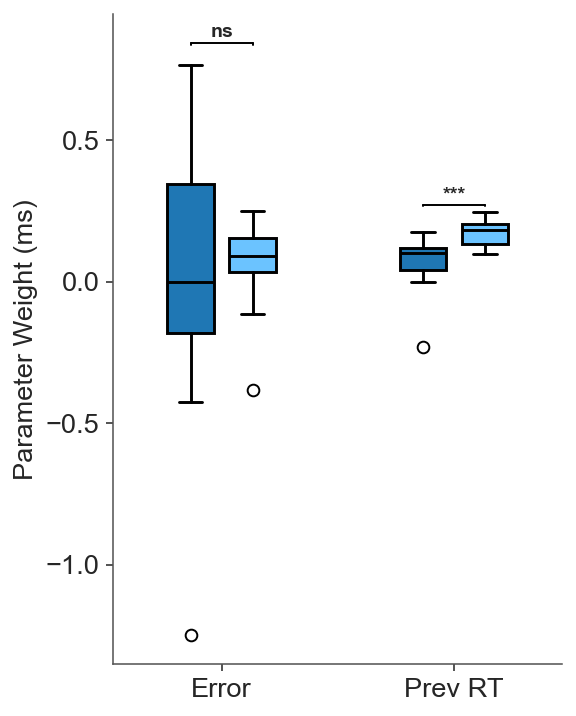

In [11]:
# Plot 1: Error and Previous RT Covariates
fig, ax = plt.subplots(figsize=(4, 5))

# Data for boxplots
error_data = [fast_df['error'], slow_df['error']]
prev_rt_data = [fast_df['prev_rt'], slow_df['prev_rt']]

# Create positions for boxplots
positions_error = [1, 1.4]
positions_prev_rt = [2.5, 2.9]

# Create boxplots
bp1 = ax.boxplot(error_data, positions=positions_error, widths=0.3, patch_artist=True)
bp2 = ax.boxplot(prev_rt_data, positions=positions_prev_rt, widths=0.3, patch_artist=True)

# Color the boxes
colors_list = [rt_color_fast_hex, rt_color_slow_hex]
for bp, box_colors in [(bp1, colors_list), (bp2, colors_list)]:
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)
    
    # Style other elements
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(1.5)

# Add significance testing between fast and slow for each parameter
new_max_height1 = add_simple_significance_bar(ax, fast_df['error'], slow_df['error'], 
                                             positions_error[0], positions_error[1], 0.1)
new_max_height2 = add_simple_significance_bar(ax, fast_df['prev_rt'], slow_df['prev_rt'], 
                                             positions_prev_rt[0], positions_prev_rt[1], 0.1)

# Set labels and formatting
ax.set_xticks([1.2, 2.7])
ax.set_xticklabels(['Error', 'Prev RT'])
ax.set_ylabel('Parameter Weight (ms)')
# ax.set_title('RT Covariates: Fast vs Slow States')

# Adjust y-axis to accommodate significance bars if needed
if new_max_height1 or new_max_height2:
    ylim = ax.get_ylim()
    max_sig_height = max([h for h in [new_max_height1, new_max_height2] if h is not None], default=0)
    if max_sig_height > 0:
        ax.set_ylim(ylim[0], max(ylim[1], max_sig_height * 1.05))

# Add legend
# 
# legend_elements = [Patch(facecolor=rt_color_fast_hex, edgecolor='black', label='Fast'),
#                    Patch(facecolor=rt_color_slow_hex, edgecolor='black', label='Slow')]
# ax.legend(handles=legend_elements, loc='upper right')

# plt.tight_layout()
plt.show()

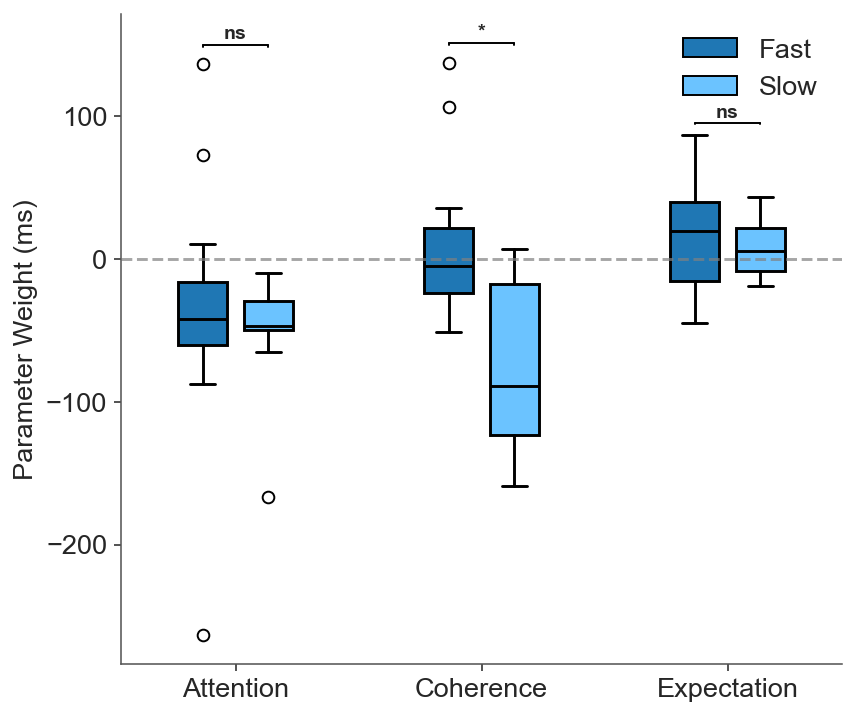

In [12]:
# Plot 2: Manipulation Effects (Attention, Coherence, Expectation)
fig, ax = plt.subplots(figsize=(6, 5))

# Data for boxplots
att_data = [fast_df['Att'], slow_df['Att']]
coh_data = [fast_df['Coh'], slow_df['Coh']]
exp_data = [fast_df['Exp'], slow_df['Exp']]

# Create positions for boxplots
positions_att = [1, 1.4]
positions_coh = [2.5, 2.9]
positions_exp = [4, 4.4]

# Create boxplots
bp1 = ax.boxplot(att_data, positions=positions_att, widths=0.3, patch_artist=True)
bp2 = ax.boxplot(coh_data, positions=positions_coh, widths=0.3, patch_artist=True)
bp3 = ax.boxplot(exp_data, positions=positions_exp, widths=0.3, patch_artist=True)

# Color the boxes
colors_list = [rt_color_fast_hex, rt_color_slow_hex]
for bp in [bp1, bp2, bp3]:
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)
    
    # Style other elements
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(1.5)

# Add significance testing between fast and slow for each manipulation
new_max_height1 = add_simple_significance_bar(ax, fast_df['Att'], slow_df['Att'], 
                                             positions_att[0], positions_att[1], 0.1)
new_max_height2 = add_simple_significance_bar(ax, fast_df['Coh'], slow_df['Coh'], 
                                             positions_coh[0], positions_coh[1], 0.1)
new_max_height3 = add_simple_significance_bar(ax, fast_df['Exp'], slow_df['Exp'], 
                                             positions_exp[0], positions_exp[1], 0.1)

# Set labels and formatting
ax.set_xticks([1.2, 2.7, 4.2])
ax.set_xticklabels(['Attention', 'Coherence', 'Expectation'])
ax.set_ylabel('Parameter Weight (ms)')
# ax.set_title('RT Manipulation Effects: Fast vs Slow States')

# Add horizontal line at zero
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.7)

# Adjust y-axis to accommodate significance bars if needed
if any([new_max_height1, new_max_height2, new_max_height3]):
    ylim = ax.get_ylim()
    max_sig_height = max([h for h in [new_max_height1, new_max_height2, new_max_height3] if h is not None], default=0)
    if max_sig_height > 0:
        ax.set_ylim(ylim[0], max(ylim[1], max_sig_height * 1.05))

# Add legend
legend_elements = [Patch(facecolor=rt_color_fast_hex, edgecolor='black', label='Fast'),
                   Patch(facecolor=rt_color_slow_hex, edgecolor='black', label='Slow')]
ax.legend(handles=legend_elements, loc='upper right')

# plt.tight_layout()
plt.show()

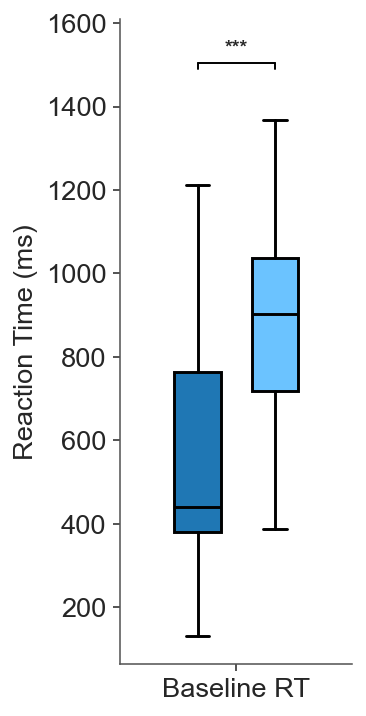

In [13]:
# Plot 3: Intercepts (Baseline RT)
fig, ax = plt.subplots(figsize=(2.5, 5))

# Data for boxplots
intercept_data = [fast_df['intercept'], slow_df['intercept']]

# Create positions for boxplots
positions = [1, 1.5]

# Create boxplot
bp = ax.boxplot(intercept_data, positions=positions, widths=0.3, patch_artist=True)

# Color the boxes
colors_list = [rt_color_fast_hex, rt_color_slow_hex]
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style other elements
for element in ['whiskers', 'fliers', 'medians', 'caps']:
    for item in bp[element]:
        item.set_color('black')
        item.set_linewidth(1.5)

# Add significance testing between fast and slow intercepts
new_max_height = add_simple_significance_bar(ax, fast_df['intercept'], slow_df['intercept'], 
                                           positions[0], positions[1], 0.1)

# Set labels and formatting
ax.set_xticks([1.25])
ax.set_xticklabels(['Baseline RT'])
ax.set_ylabel('Reaction Time (ms)')
# ax.set_title('RT Intercepts: Fast vs Slow States')
ax.set_xlim(0.5, 2.0)  # Tighter x-axis limits

# Adjust y-axis to accommodate significance bars if needed
if new_max_height:
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], max(ylim[1], new_max_height * 1.05))

# Add legend
# legend_elements = [Patch(facecolor=rt_color_fast_hex, edgecolor='black', label='Fast'),
#                    Patch(facecolor=rt_color_slow_hex, edgecolor='black', label='Slow')]
# ax.legend(handles=legend_elements, loc='upper right')

# plt.tight_layout()
plt.show()

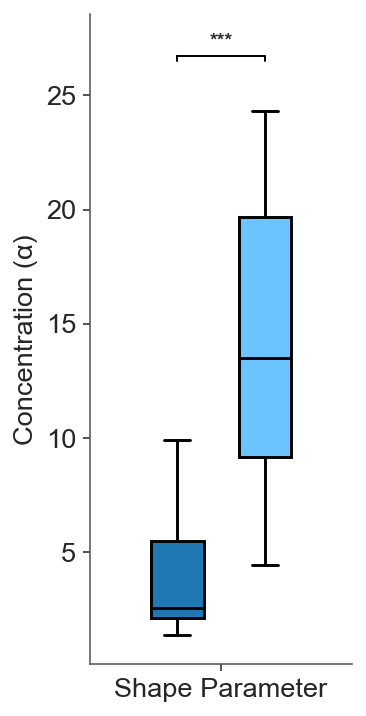

In [14]:
# Plot 4: Shape Parameters (Alpha/Concentration)
fig, ax = plt.subplots(figsize=(2.5, 5))

# Data for boxplots - flatten concentration values properly
fast_conc_flat = np.array(fast_concentration).flatten()
slow_conc_flat = np.array(slow_concentration).flatten()
concentration_data = [fast_conc_flat, slow_conc_flat]

# Create positions for boxplots
positions = [1, 1.5]

# Create boxplot
bp = ax.boxplot(concentration_data, positions=positions, widths=0.3, patch_artist=True)

# Color the boxes
colors_list = [rt_color_fast_hex, rt_color_slow_hex]
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style other elements
for element in ['whiskers', 'fliers', 'medians', 'caps']:
    for item in bp[element]:
        item.set_color('black')
        item.set_linewidth(1.5)

# Add significance testing between fast and slow concentration parameters
new_max_height = add_simple_significance_bar(ax, fast_conc_flat, slow_conc_flat, 
                                           positions[0], positions[1], 0.1)

# Set labels and formatting
ax.set_xticks([1.25])
ax.set_xticklabels(['Shape Parameter'])
ax.set_ylabel('Concentration (α)')
# ax.set_title('RT Shape Parameters: Fast vs Slow States')
ax.set_xlim(0.5, 2.0)  # Tighter x-axis limits

# Adjust y-axis to accommodate significance bars if needed
if new_max_height:
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], max(ylim[1], new_max_height * 1.05))

# Add legend
# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor=rt_color_fast_hex, edgecolor='black', label='Fast'),
#                    Patch(facecolor=rt_color_slow_hex, edgecolor='black', label='Slow')]
# ax.legend(handles=legend_elements, loc='upper right')

# plt.tight_layout()
plt.show()

# RA VIZ

In [15]:
all_state_0 = np.array([ ra_sub_params[i][2].emissions.w1[0] for i in range(12) ])
all_state_1 = np.array([ ra_sub_params[i][2].emissions.w1[1] for i in range(12) ])

all_concen_0 = np.array([ ra_sub_params[i][2].emissions.w2[0] for i in range(12) ])
all_concen_1 = np.array([ ra_sub_params[i][2].emissions.w2[1] for i in range(12) ])

trans_ra = [ ra_sub_params[i][2].transitions.transition_matrix for i in range(12) ]
trans_ra = np.array(trans_ra)

engaged_transitions = []
disengaged_transitions = []

engaged_params = []
disengaged_params = []

engaged_concentration = []
disengaged_concentration = []

engaged_post = []
disengaged_post = []

for i in range(12):
    # if the 1th (stimulus) absolute value is larger than then keep in engaged
    if np.abs(all_state_1[i][1])* all_concen_1[i] > np.abs(all_state_0[i][1])* all_concen_0[i]:
        engaged_params.append(all_state_1[i])
        disengaged_params.append(all_state_0[i])
        
        engaged_concentration.append(all_concen_1[i])
        disengaged_concentration.append(all_concen_0[i])
        
        engaged_transitions.append(trans_ra[i][1])
        disengaged_transitions.append(trans_ra[i][0])
        
        engaged_post.append(ra_smoothed_posteriors[i].smoothed_probs[:, :, 1])
        disengaged_post.append(ra_smoothed_posteriors[i].smoothed_probs[:, :, 0])
    else:
        engaged_params.append(all_state_0[i])
        disengaged_params.append(all_state_1[i])
        
        engaged_concentration.append(all_concen_0[i])
        disengaged_concentration.append(all_concen_1[i])
        
        engaged_transitions.append(trans_ra[i][0])
        disengaged_transitions.append(trans_ra[i][1])
        
        engaged_post.append(ra_smoothed_posteriors[i].smoothed_probs[:, :, 0])
        disengaged_post.append(ra_smoothed_posteriors[i].smoothed_probs[:, :, 1])


In [16]:
# Restore colors variable if it gets overwritten
colors = ('#1f77b4', '#ff7f0e', '#2ca02c')
print("Colors restored:", colors)

Colors restored: ('#1f77b4', '#ff7f0e', '#2ca02c')


In [17]:
# Define colors for RA visualization
# Get the orange color and create a lighter variant
ra_color_engaged = colors[1]  # Regular orange for engaged
ra_color_engaged_rgb = mpl.colors.to_rgb(ra_color_engaged)

# Convert to HSV, reduce saturation and increase brightness for disengaged
h, s, v = colorsys.rgb_to_hsv(*ra_color_engaged_rgb)
ra_color_disengaged_rgb = colorsys.hsv_to_rgb(h, s * 0.7, min(1.0, v + 0.3))

# Convert to hex for easier handling
ra_color_engaged_hex = mpl.colors.to_hex(ra_color_engaged)
ra_color_disengaged_hex = mpl.colors.to_hex(ra_color_disengaged_rgb)

# Prepare the data for plotting
ra_column_names = ["intercept", "stim", "prev_stim", "prev_resp", "Att", "Coh", "Exp"]

# Create dataframes - RA parameters don't need exponential transformation like RT just need to be converted to degrees
engaged_df = pd.DataFrame(np.array(engaged_params), columns=ra_column_names) * (180 / np.pi)
disengaged_df = pd.DataFrame(np.array(disengaged_params), columns=ra_column_names) * (180 / np.pi)

print(f"Engaged RA color: {ra_color_engaged_hex}")
print(f"Disengaged RA color: {ra_color_disengaged_hex}")
print(f"Data shapes - Engaged: {engaged_df.shape}, Disengaged: {disengaged_df.shape}")

Engaged RA color: #ff7f0e
Disengaged RA color: #ffa556
Data shapes - Engaged: (12, 7), Disengaged: (12, 7)


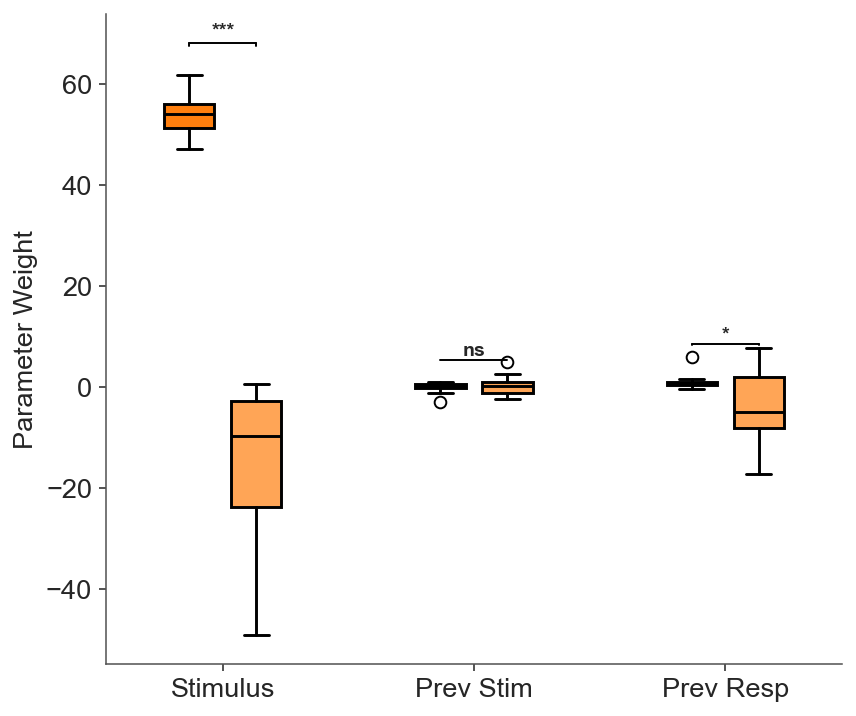

In [18]:
# Plot 1: Stimulus and History Covariates for RA
fig, ax = plt.subplots(figsize=(6, 5))

# Data for boxplots
stim_data = [engaged_df['stim'], disengaged_df['stim']]
prev_stim_data = [engaged_df['prev_stim'], disengaged_df['prev_stim']]
prev_resp_data = [engaged_df['prev_resp'], disengaged_df['prev_resp']]

# Create positions for boxplots
positions_stim = [1, 1.4]
positions_prev_stim = [2.5, 2.9]
positions_prev_resp = [4, 4.4]

# Create boxplots
bp1 = ax.boxplot(stim_data, positions=positions_stim, widths=0.3, patch_artist=True)
bp2 = ax.boxplot(prev_stim_data, positions=positions_prev_stim, widths=0.3, patch_artist=True)
bp3 = ax.boxplot(prev_resp_data, positions=positions_prev_resp, widths=0.3, patch_artist=True)

# Color the boxes
colors_list = [ra_color_engaged_hex, ra_color_disengaged_hex]
for bp in [bp1, bp2, bp3]:
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)
    
    # Style other elements
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(1.5)

# Add significance testing between engaged and disengaged for each parameter
new_max_height1 = add_simple_significance_bar(ax, engaged_df['stim'], disengaged_df['stim'], 
                                             positions_stim[0], positions_stim[1], 0.1)
new_max_height2 = add_simple_significance_bar(ax, engaged_df['prev_stim'], disengaged_df['prev_stim'], 
                                             positions_prev_stim[0], positions_prev_stim[1], 0.1)
new_max_height3 = add_simple_significance_bar(ax, engaged_df['prev_resp'], disengaged_df['prev_resp'], 
                                             positions_prev_resp[0], positions_prev_resp[1], 0.1)

# Set labels and formatting
ax.set_xticks([1.2, 2.7, 4.2])
ax.set_xticklabels(['Stimulus', 'Prev Stim', 'Prev Resp'])
ax.set_ylabel('Parameter Weight')
# ax.set_title('RA Stimulus & History: Engaged vs Disengaged States')

# Adjust y-axis to accommodate significance bars if needed
if any([new_max_height1, new_max_height2, new_max_height3]):
    ylim = ax.get_ylim()
    max_sig_height = max([h for h in [new_max_height1, new_max_height2, new_max_height3] if h is not None], default=0)
    if max_sig_height > 0:
        ax.set_ylim(ylim[0], max(ylim[1], max_sig_height * 1.05))

# Add legend
# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor=ra_color_engaged_hex, edgecolor='black', label='Engaged'),
#                    Patch(facecolor=ra_color_disengaged_hex, edgecolor='black', label='Disengaged')]
# ax.legend(handles=legend_elements, loc='upper right')

# plt.tight_layout()
plt.show()

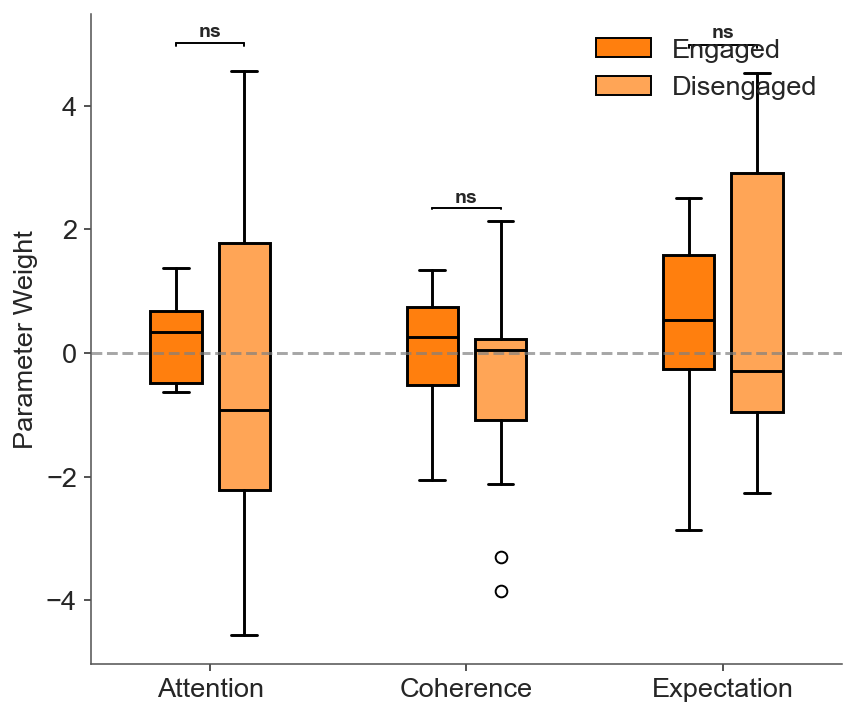

In [19]:
# Plot 2: Manipulation Effects for RA (Attention, Coherence, Expectation)
fig, ax = plt.subplots(figsize=(6, 5))

# Data for boxplots
att_data = [engaged_df['Att'], disengaged_df['Att']]
coh_data = [engaged_df['Coh'], disengaged_df['Coh']]
exp_data = [engaged_df['Exp'], disengaged_df['Exp']]

# Create positions for boxplots
positions_att = [1, 1.4]
positions_coh = [2.5, 2.9]
positions_exp = [4, 4.4]

# Create boxplots
bp1 = ax.boxplot(att_data, positions=positions_att, widths=0.3, patch_artist=True)
bp2 = ax.boxplot(coh_data, positions=positions_coh, widths=0.3, patch_artist=True)
bp3 = ax.boxplot(exp_data, positions=positions_exp, widths=0.3, patch_artist=True)

# Color the boxes
colors_list = [ra_color_engaged_hex, ra_color_disengaged_hex]
for bp in [bp1, bp2, bp3]:
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)
    
    # Style other elements
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(1.5)

# Add significance testing between engaged and disengaged for each manipulation
new_max_height1 = add_simple_significance_bar(ax, engaged_df['Att'], disengaged_df['Att'], 
                                             positions_att[0], positions_att[1], 0.1)
new_max_height2 = add_simple_significance_bar(ax, engaged_df['Coh'], disengaged_df['Coh'], 
                                             positions_coh[0], positions_coh[1], 0.1)
new_max_height3 = add_simple_significance_bar(ax, engaged_df['Exp'], disengaged_df['Exp'], 
                                             positions_exp[0], positions_exp[1], 0.1)

# Set labels and formatting
ax.set_xticks([1.2, 2.7, 4.2])
ax.set_xticklabels(['Attention', 'Coherence', 'Expectation'])
ax.set_ylabel('Parameter Weight')
# ax.set_title('RA Manipulation Effects: Engaged vs Disengaged States')

# Add horizontal line at zero
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.7)

# Adjust y-axis to accommodate significance bars if needed
if any([new_max_height1, new_max_height2, new_max_height3]):
    ylim = ax.get_ylim()
    max_sig_height = max([h for h in [new_max_height1, new_max_height2, new_max_height3] if h is not None], default=0)
    if max_sig_height > 0:
        ax.set_ylim(ylim[0], max(ylim[1], max_sig_height * 1.05))
        
# Add legend
# from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=ra_color_engaged_hex, edgecolor='black', label='Engaged'),
                   Patch(facecolor=ra_color_disengaged_hex, edgecolor='black', label='Disengaged')]
ax.legend(handles=legend_elements, loc='upper right')


# plt.tight_layout()
plt.show()

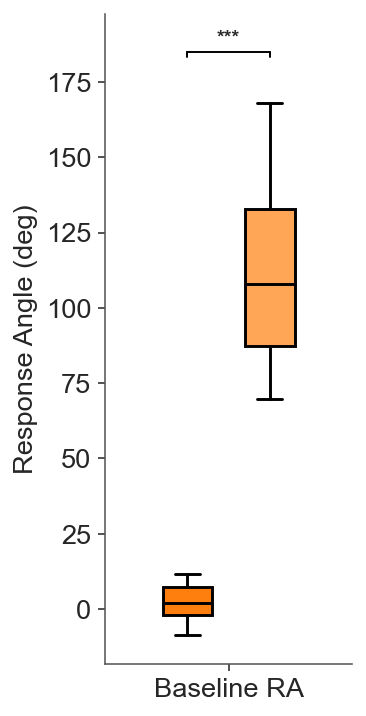

In [20]:
# Plot 3: Intercepts for RA (Baseline Response Angle)
fig, ax = plt.subplots(figsize=(2.5, 5))

# Data for boxplots
intercept_data = [engaged_df['intercept'], disengaged_df['intercept']]

# Create positions for boxplots
positions = [1, 1.5]

# Create boxplot
bp = ax.boxplot(intercept_data, positions=positions, widths=0.3, patch_artist=True)

# Color the boxes
colors_list = [ra_color_engaged_hex, ra_color_disengaged_hex]
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style other elements
for element in ['whiskers', 'fliers', 'medians', 'caps']:
    for item in bp[element]:
        item.set_color('black')
        item.set_linewidth(1.5)

# Add significance testing between engaged and disengaged intercepts
new_max_height = add_simple_significance_bar(ax, engaged_df['intercept'], disengaged_df['intercept'], 
                                           positions[0], positions[1], 0.1)

# Set labels and formatting
ax.set_xticks([1.25])
ax.set_xticklabels(['Baseline RA'])
ax.set_ylabel('Response Angle (deg)')
# ax.set_title('RA Intercepts: Engaged vs Disengaged States')
ax.set_xlim(0.5, 2.0)  # Tighter x-axis limits

# Adjust y-axis to accommodate significance bars if needed
if new_max_height:
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], max(ylim[1], new_max_height * 1.05))

# plt.tight_layout()
plt.show()

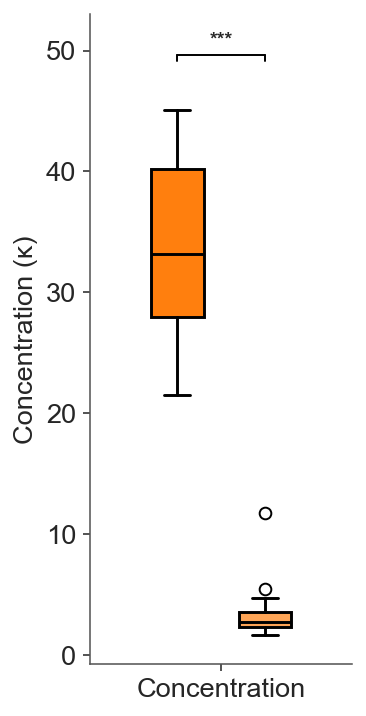

In [21]:
# Plot 4: Concentration Parameters (Kappa) for RA - Von Mises GLM
fig, ax = plt.subplots(figsize=(2.5, 5))

# Data for boxplots - flatten concentration values properly
engaged_conc_flat = np.array(engaged_concentration).flatten()
disengaged_conc_flat = np.array(disengaged_concentration).flatten()
concentration_data = [engaged_conc_flat, disengaged_conc_flat]

# Create positions for boxplots
positions = [1, 1.5]

# Create boxplot
bp = ax.boxplot(concentration_data, positions=positions, widths=0.3, patch_artist=True)

# Color the boxes
colors_list = [ra_color_engaged_hex, ra_color_disengaged_hex]
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style other elements
for element in ['whiskers', 'fliers', 'medians', 'caps']:
    for item in bp[element]:
        item.set_color('black')
        item.set_linewidth(1.5)

# Add significance testing between engaged and disengaged concentration parameters
new_max_height = add_simple_significance_bar(ax, engaged_conc_flat, disengaged_conc_flat, 
                                           positions[0], positions[1], 0.1)

# Set labels and formatting
ax.set_xticks([1.25])
ax.set_xticklabels(['Concentration'])
ax.set_ylabel('Concentration (κ)')
# ax.set_title('RA Concentration Parameters: Engaged vs Disengaged States')
ax.set_xlim(0.5, 2.0)  # Tighter x-axis limits

# Adjust y-axis to accommodate significance bars if needed
if new_max_height:
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], max(ylim[1], new_max_height * 1.05))

# plt.tight_layout()
plt.show()

# RE VIZ

In [22]:
all_state_0 = np.array([ re_sub_params[i][2].emissions.w1[0] for i in range(12) ])
all_state_1 = np.array([ re_sub_params[i][2].emissions.w1[1] for i in range(12) ])

all_concen_0 = np.array([ re_sub_params[i][2].emissions.w2[0] for i in range(12) ])
all_concen_1 = np.array([ re_sub_params[i][2].emissions.w2[1] for i in range(12) ])

trans_ra = [ re_sub_params[i][2].transitions.transition_matrix for i in range(12) ]
trans_ra = np.array(trans_ra)

accurate_transitions = []
erratic_transitions = []

accurate_params = []
erratic_params = []

accurate_concentration = []
erratic_concentration = []

accurate_post = []
erratic_post = []

for i in range(12):
    # if the 1th (stimulus) absolute value is larger than then keep in accurate
    if all_concen_1[i] < all_concen_0[i]:
        accurate_params.append(all_state_1[i])
        erratic_params.append(all_state_0[i])
        
        accurate_concentration.append(all_concen_1[i])
        erratic_concentration.append(all_concen_0[i])
        
        accurate_transitions.append(trans_ra[i][1])
        erratic_transitions.append(trans_ra[i][0])
        
        accurate_post.append(re_smoothed_posteriors[i].smoothed_probs[:, :, 1])
        erratic_post.append(re_smoothed_posteriors[i].smoothed_probs[:, :, 0])
    else:
        accurate_params.append(all_state_0[i])
        erratic_params.append(all_state_1[i])
        
        accurate_concentration.append(all_concen_0[i])
        erratic_concentration.append(all_concen_1[i])
        
        accurate_transitions.append(trans_ra[i][0])
        erratic_transitions.append(trans_ra[i][1])
        
        accurate_post.append(re_smoothed_posteriors[i].smoothed_probs[:, :, 0])
        erratic_post.append(re_smoothed_posteriors[i].smoothed_probs[:, :, 1])
    

In [23]:
# Define colors for RE visualization
# Get the green color and create a lighter variant
re_color_accurate = colors[2]  # Regular green for accurate
re_color_accurate_rgb = mpl.colors.to_rgb(re_color_accurate)

# Convert to HSV, reduce saturation and increase brightness for erratic
h, s, v = colorsys.rgb_to_hsv(*re_color_accurate_rgb)
re_color_erratic_rgb = colorsys.hsv_to_rgb(h, s * 0.7, min(1.0, v + 0.3))

# Convert to hex for easier handling
re_color_accurate_hex = mpl.colors.to_hex(re_color_accurate)
re_color_erratic_hex = mpl.colors.to_hex(re_color_erratic_rgb)

# Prepare the data for plotting
re_column_names = ["intercept", "RT", "Prev_Error", "Att", "Coh", "Exp"]

# Create dataframes - RE parameters come from a normal glm and do not need exponential transformation
accurate_df = pd.DataFrame(np.array(accurate_params), columns=re_column_names)
erratic_df = pd.DataFrame(np.array(erratic_params), columns=re_column_names)

print(f"Accurate RE color: {re_color_accurate_hex}")
print(f"Erratic RE color: {re_color_erratic_hex}")
print(f"Data shapes - Accurate: {accurate_df.shape}, Erratic: {erratic_df.shape}")

Accurate RE color: #2ca02c
Erratic RE color: #74ec74
Data shapes - Accurate: (12, 6), Erratic: (12, 6)


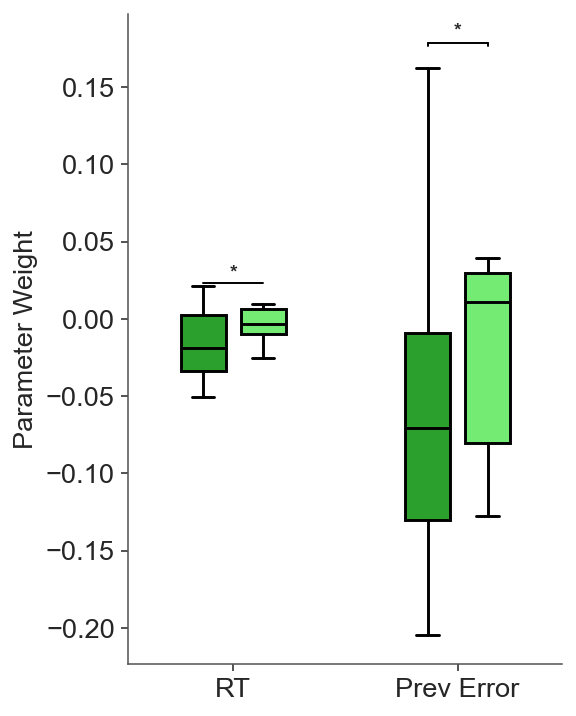

In [24]:
# Plot 1: RT and Previous Error Covariates for RE
fig, ax = plt.subplots(figsize=(4, 5))

# Data for boxplots
rt_data = [accurate_df['RT'], erratic_df['RT']]
prev_error_data = [accurate_df['Prev_Error'], erratic_df['Prev_Error']]

# Create positions for boxplots
positions_rt = [1, 1.4]
positions_prev_error = [2.5, 2.9]

# Create boxplots
bp1 = ax.boxplot(rt_data, positions=positions_rt, widths=0.3, patch_artist=True)
bp2 = ax.boxplot(prev_error_data, positions=positions_prev_error, widths=0.3, patch_artist=True)

# Color the boxes
colors_list = [re_color_accurate_hex, re_color_erratic_hex]
for bp, box_colors in [(bp1, colors_list), (bp2, colors_list)]:
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)
    
    # Style other elements
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(1.5)

# Add significance testing between accurate and erratic for each parameter
new_max_height1 = add_simple_significance_bar(ax, accurate_df['RT'], erratic_df['RT'], 
                                             positions_rt[0], positions_rt[1], 0.1)
new_max_height2 = add_simple_significance_bar(ax, accurate_df['Prev_Error'], erratic_df['Prev_Error'], 
                                             positions_prev_error[0], positions_prev_error[1], 0.1)

# Set labels and formatting
ax.set_xticks([1.2, 2.7])
ax.set_xticklabels(['RT', 'Prev Error'])
ax.set_ylabel('Parameter Weight')
# ax.set_title('RE Covariates: Accurate vs Erratic States')

# Adjust y-axis to accommodate significance bars if needed
if new_max_height1 or new_max_height2:
    ylim = ax.get_ylim()
    max_sig_height = max([h for h in [new_max_height1, new_max_height2] if h is not None], default=0)
    if max_sig_height > 0:
        ax.set_ylim(ylim[0], max(ylim[1], max_sig_height * 1.05))

# Add legend
# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor=re_color_accurate_hex, edgecolor='black', label='Accurate'),
#                    Patch(facecolor=re_color_erratic_hex, edgecolor='black', label='Erratic')]
# ax.legend(handles=legend_elements, loc='upper right')

# plt.tight_layout()
plt.show()

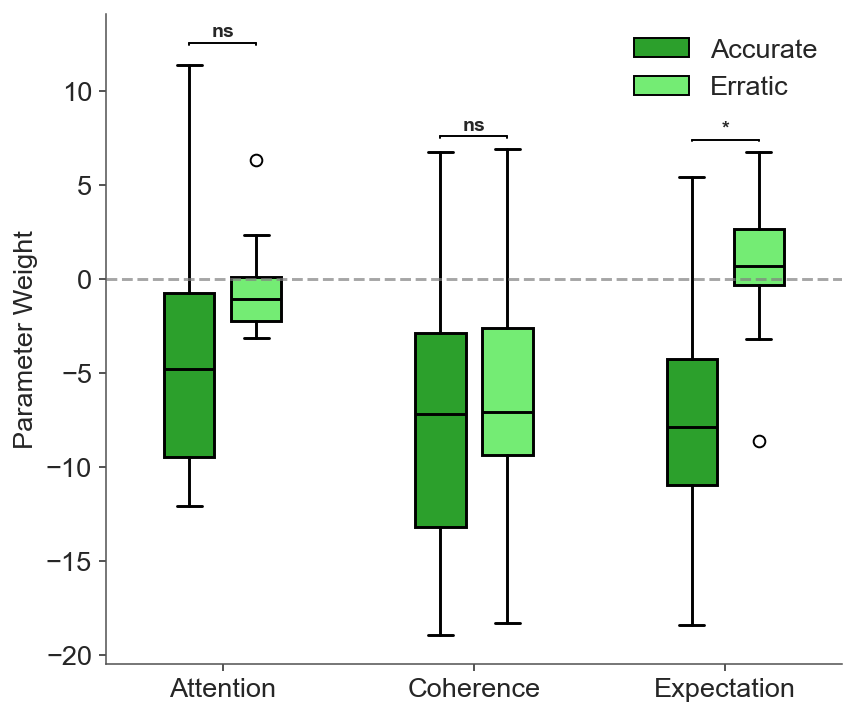

In [25]:
# Plot 2: Manipulation Effects for RE (Attention, Coherence, Expectation)
fig, ax = plt.subplots(figsize=(6, 5))

# Data for boxplots
att_data = [accurate_df['Att'], erratic_df['Att']]
coh_data = [accurate_df['Coh'], erratic_df['Coh']]
exp_data = [accurate_df['Exp'], erratic_df['Exp']]

# Create positions for boxplots
positions_att = [1, 1.4]
positions_coh = [2.5, 2.9]
positions_exp = [4, 4.4]

# Create boxplots
bp1 = ax.boxplot(att_data, positions=positions_att, widths=0.3, patch_artist=True)
bp2 = ax.boxplot(coh_data, positions=positions_coh, widths=0.3, patch_artist=True)
bp3 = ax.boxplot(exp_data, positions=positions_exp, widths=0.3, patch_artist=True)

# Color the boxes
colors_list = [re_color_accurate_hex, re_color_erratic_hex]
for bp in [bp1, bp2, bp3]:
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)
    
    # Style other elements
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(1.5)

# Add significance testing between accurate and erratic for each manipulation
new_max_height1 = add_simple_significance_bar(ax, accurate_df['Att'], erratic_df['Att'], 
                                             positions_att[0], positions_att[1], 0.1)
new_max_height2 = add_simple_significance_bar(ax, accurate_df['Coh'], erratic_df['Coh'], 
                                             positions_coh[0], positions_coh[1], 0.1)
new_max_height3 = add_simple_significance_bar(ax, accurate_df['Exp'], erratic_df['Exp'], 
                                             positions_exp[0], positions_exp[1], 0.1)

# Set labels and formatting
ax.set_xticks([1.2, 2.7, 4.2])
ax.set_xticklabels(['Attention', 'Coherence', 'Expectation'])
ax.set_ylabel('Parameter Weight')
# ax.set_title('RE Manipulation Effects: Accurate vs Erratic States')

# Add horizontal line at zero
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.7)

# Adjust y-axis to accommodate significance bars if needed
if any([new_max_height1, new_max_height2, new_max_height3]):
    ylim = ax.get_ylim()
    max_sig_height = max([h for h in [new_max_height1, new_max_height2, new_max_height3] if h is not None], default=0)
    if max_sig_height > 0:
        ax.set_ylim(ylim[0], max(ylim[1], max_sig_height * 1.05))

# Add legend
# from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=re_color_accurate_hex, edgecolor='black', label='Accurate'),
                   Patch(facecolor=re_color_erratic_hex, edgecolor='black', label='Erratic')]
ax.legend(handles=legend_elements, loc='upper right')

# plt.tight_layout()
plt.show()

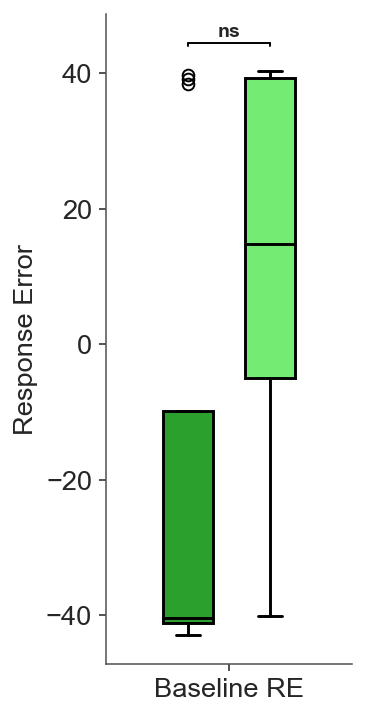

In [26]:
# Plot 3: Intercepts for RE (Baseline Response Error)
fig, ax = plt.subplots(figsize=(2.5, 5))

# Data for boxplots
intercept_data = [accurate_df['intercept'], erratic_df['intercept']]

# Create positions for boxplots
positions = [1, 1.5]

# Create boxplot
bp = ax.boxplot(intercept_data, positions=positions, widths=0.3, patch_artist=True)

# Color the boxes
colors_list = [re_color_accurate_hex, re_color_erratic_hex]
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style other elements
for element in ['whiskers', 'fliers', 'medians', 'caps']:
    for item in bp[element]:
        item.set_color('black')
        item.set_linewidth(1.5)

# Add significance testing between accurate and erratic intercepts
new_max_height = add_simple_significance_bar(ax, accurate_df['intercept'], erratic_df['intercept'], 
                                           positions[0], positions[1], 0.1)

# Set labels and formatting
ax.set_xticks([1.25])
ax.set_xticklabels(['Baseline RE'])
ax.set_ylabel('Response Error')
# ax.set_title('RE Intercepts: Accurate vs Erratic States')
ax.set_xlim(0.5, 2.0)  # Tighter x-axis limits

# Adjust y-axis to accommodate significance bars if needed
if new_max_height:
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], max(ylim[1], new_max_height * 1.05))

# plt.tight_layout()
plt.show()

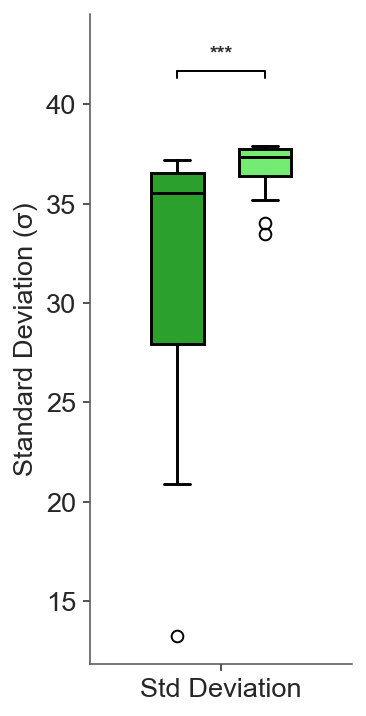

In [27]:
# Plot 4: Standard Deviation Parameters for RE - Normal GLM
fig, ax = plt.subplots(figsize=(2.5, 5))

# Data for boxplots - flatten concentration values properly (these are std dev parameters)
accurate_conc_flat = np.array(accurate_concentration).flatten()
erratic_conc_flat = np.array(erratic_concentration).flatten()
concentration_data = [accurate_conc_flat, erratic_conc_flat]

# Create positions for boxplots
positions = [1, 1.5]

# Create boxplot
bp = ax.boxplot(concentration_data, positions=positions, widths=0.3, patch_artist=True)

# Color the boxes
colors_list = [re_color_accurate_hex, re_color_erratic_hex]
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style other elements
for element in ['whiskers', 'fliers', 'medians', 'caps']:
    for item in bp[element]:
        item.set_color('black')
        item.set_linewidth(1.5)

# Add significance testing between accurate and erratic std dev parameters
new_max_height = add_simple_significance_bar(ax, accurate_conc_flat, erratic_conc_flat, 
                                           positions[0], positions[1], 0.1)

# Set labels and formatting
ax.set_xticks([1.25])
ax.set_xticklabels(['Std Deviation'])
ax.set_ylabel('Standard Deviation (σ)')
# ax.set_title('RE Standard Deviation: Accurate vs Erratic States')
ax.set_xlim(0.5, 2.0)  # Tighter x-axis limits

# Adjust y-axis to accommodate significance bars if needed
if new_max_height:
    ylim = ax.get_ylim()
    ax.set_ylim(ylim[0], max(ylim[1], new_max_height * 1.05))

# plt.tight_layout()
plt.show()